# Unsupervised Clustering of Facial Features

This notebook clusters faces based solely on numeric geometric and expression features,
then evaluates whether the discovered clusters align with known demographic categories
(gender, ethnicity, dataset).

In [1]:
# Parameters cell (papermill will inject values here)
data_path = "data/features.csv"
output_dir = "data/plots/clustering"

In [2]:
# Parameters
data_path = "data/features.csv"
output_dir = "data/plots/clustering"


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
)
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 120

out = Path(output_dir)
out.mkdir(parents=True, exist_ok=True)
print("Setup complete.")

Setup complete.


## 1. Load and Prepare Data

In [4]:
df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape}")
print(f"\nGender distribution:\n{df['gender'].value_counts()}")
print(f"\nEthnicity distribution:\n{df['ethnicity'].value_counts()}")
print(f"\nDataset distribution:\n{df['dataset'].value_counts()}")

Dataset shape: (17870, 52)

Gender distribution:
gender
unknown    10000
female      4087
male        3783
Name: count, dtype: int64

Ethnicity distribution:
ethnicity
asian         14351
caucasian      2480
hispanic        296
black           296
mideastern      291
indian          156
Name: count, dtype: int64

Dataset distribution:
dataset
livebeauty    10000
scut           5500
mebeauty       2370
Name: count, dtype: int64


In [5]:
# Define numeric feature columns (geometry + expression)
GEOMETRY_FEATURES = [
    "canthal_tilt", "eye_width_ratio", "eye_height_ratio", "eyebrow_eye_dist",
    "eye_spacing_ratio", "eye_area_ratio", "scleral_show", "eye_asymmetry",
    "brow_arch_height", "nose_width_ratio", "nose_length_ratio", "nose_symmetry",
    "lip_width_ratio", "upper_lip_ratio", "lip_fullness_ratio",
    "mouth_width_face_ratio", "cupids_bow_ratio", "mouth_chin_ratio",
    "mouth_symmetry", "facial_symmetry", "face_length_width_ratio",
    "jaw_width_ratio", "interpupillary_ratio", "gonial_angle", "chin_taper",
    "eye_symmetry", "midface_ratio", "lower_face_ratio", "phi_deviation",
    "facial_thirds_symmetry",
]

EXPRESSION_FEATURES = [
    "expr_smile", "expr_frown", "expr_jaw_open", "expr_brow_up",
    "expr_brow_down", "expr_cheek_squint", "expr_eye_squint",
    "expr_eye_wide", "expr_mouth_pucker",
]

FEATURE_COLS = GEOMETRY_FEATURES + EXPRESSION_FEATURES

# Drop rows with NaNs in feature columns
df_clean = df.dropna(subset=FEATURE_COLS).copy()
print(f"Rows after dropping NaNs: {len(df_clean)} (dropped {len(df) - len(df_clean)})")

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(df_clean[FEATURE_COLS])
print(f"Feature matrix shape: {X.shape}")

Rows after dropping NaNs: 17870 (dropped 0)
Feature matrix shape: (17870, 39)


## 2. PCA for Visualization

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_clean["pca_1"] = X_pca[:, 0]
df_clean["pca_2"] = X_pca[:, 1]

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}, "
      f"Total={sum(pca.explained_variance_ratio_):.3f}")

# Also fit higher-dimensional PCA for clustering
pca_full = PCA(n_components=0.95)  # keep 95% variance
X_pca_full = pca_full.fit_transform(X)
print(f"PCA components for 95% variance: {pca_full.n_components_}")

Explained variance: PC1=0.193, PC2=0.143, Total=0.336
PCA components for 95% variance: 19


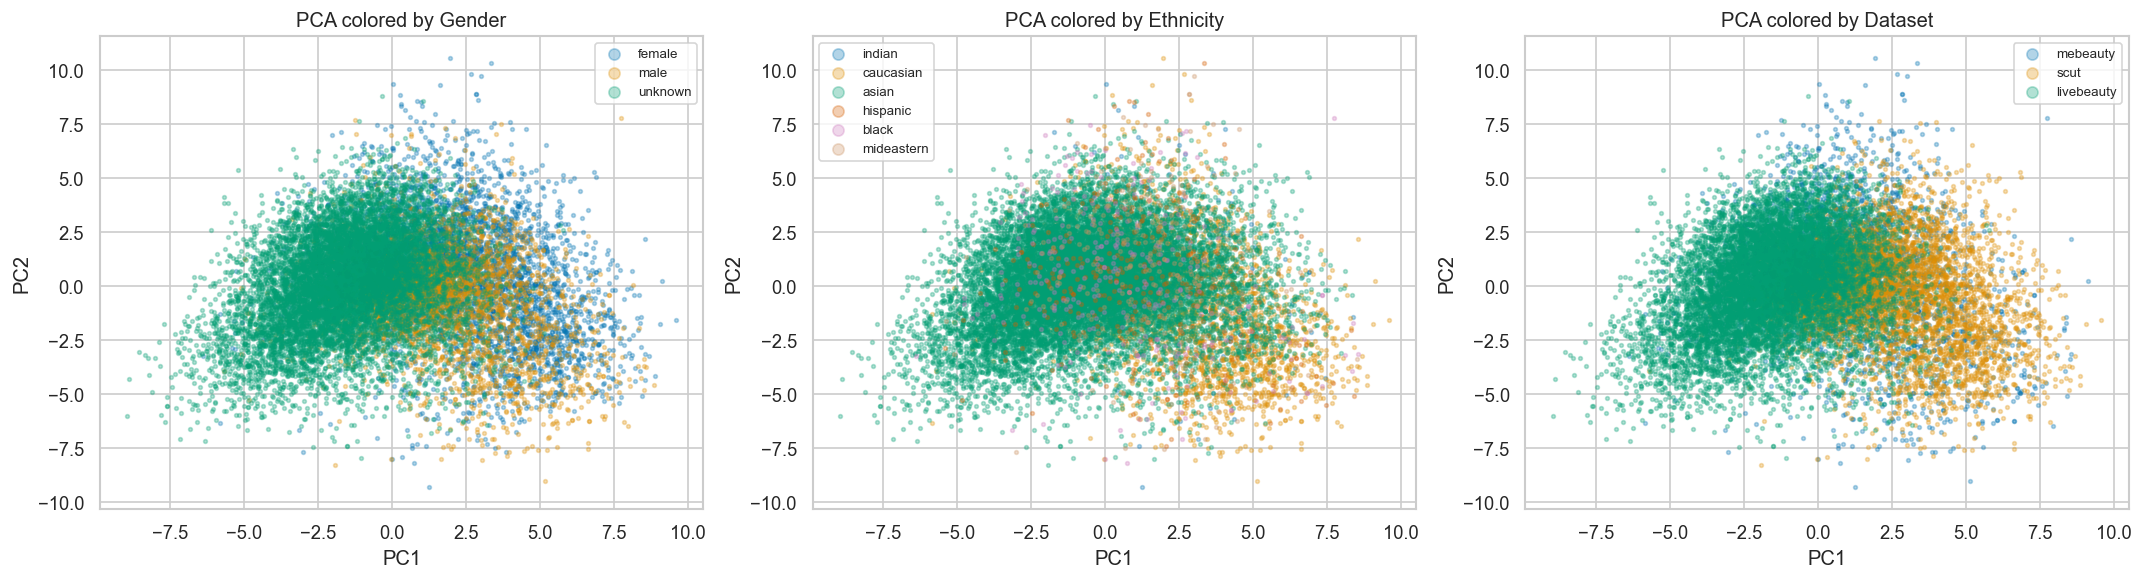

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(axes, ["gender", "ethnicity", "dataset"],
                           ["Gender", "Ethnicity", "Dataset"]):
    for label in df_clean[col].unique():
        mask = df_clean[col] == label
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.3, s=5, label=label)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"PCA colored by {title}")
    ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig(out / "pca_ground_truth.png", bbox_inches="tight")
plt.show()

## 3. Determine Optimal k (Elbow & Silhouette)

In [8]:
k_range = range(2, 15)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, sample_size=5000, random_state=42))
    print(f"  k={k:2d}: inertia={km.inertia_:.0f}, silhouette={silhouettes[-1]:.4f}")

best_k = list(k_range)[np.argmax(silhouettes)]
print(f"\nBest k by silhouette: {best_k} (score={max(silhouettes):.4f})")

  k= 2: inertia=609605, silhouette=0.1185


  k= 3: inertia=551752, silhouette=0.1441


  k= 4: inertia=504497, silhouette=0.1291


  k= 5: inertia=465961, silhouette=0.1313


  k= 6: inertia=443262, silhouette=0.1224


...

  k=10: inertia=393293, silhouette=0.1057


  k=11: inertia=386125, silhouette=0.1035


  k=12: inertia=377133, silhouette=0.1050


  k=13: inertia=370508, silhouette=0.1014


  k=14: inertia=363842, silhouette=0.1018

Best k by silhouette: 3 (score=0.1441)


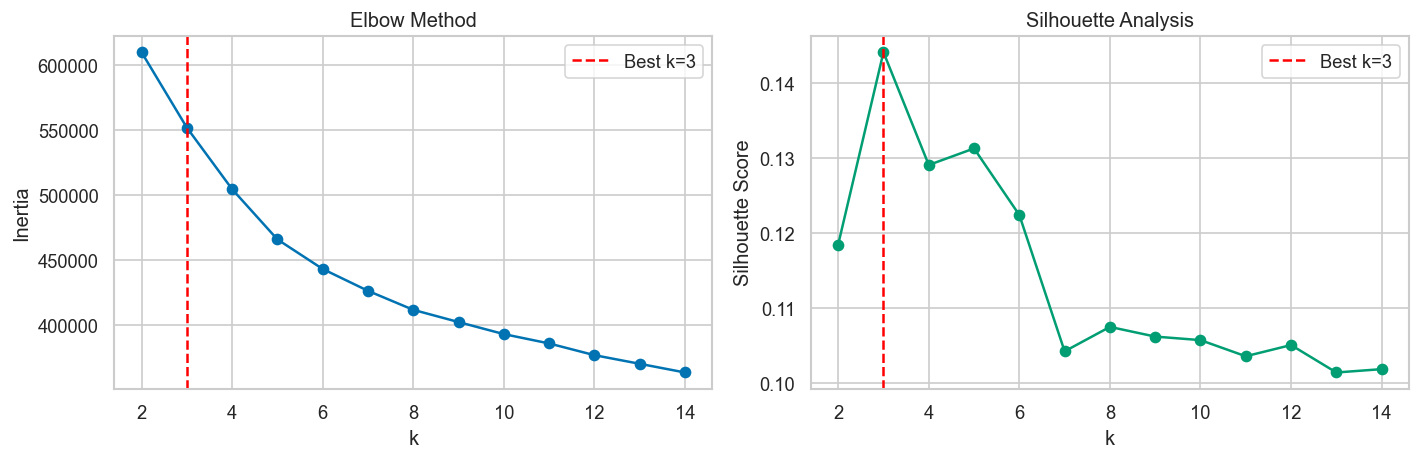

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(k_range), inertias, "bo-")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")
ax1.axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}")
ax1.legend()

ax2.plot(list(k_range), silhouettes, "go-")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Analysis")
ax2.axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}")
ax2.legend()

plt.tight_layout()
plt.savefig(out / "elbow_silhouette.png", bbox_inches="tight")
plt.show()

## 4. KMeans Clustering

In [10]:
# Category-matched k values
n_genders = df_clean["gender"].nunique()
n_ethnicities = df_clean["ethnicity"].nunique()
n_datasets = df_clean["dataset"].nunique()

print(f"Category counts -> Gender: {n_genders}, Ethnicity: {n_ethnicities}, Dataset: {n_datasets}")
print(f"Optimal k by silhouette: {best_k}")

# Run KMeans for each relevant k
k_values = sorted(set([best_k, n_genders, n_ethnicities, n_datasets]))
kmeans_results = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    df_clean[f"kmeans_k{k}"] = labels
    kmeans_results[k] = labels
    print(f"\nKMeans k={k}: silhouette={silhouette_score(X, labels, sample_size=5000, random_state=42):.4f}")

Category counts -> Gender: 3, Ethnicity: 6, Dataset: 3
Optimal k by silhouette: 3



KMeans k=3: silhouette=0.1441



KMeans k=6: silhouette=0.1224


## 5. DBSCAN Clustering

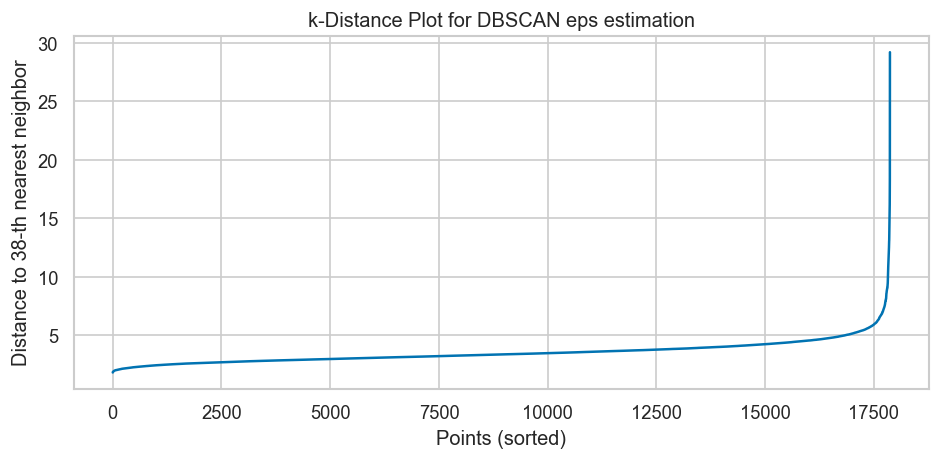

Estimated eps (90th percentile): 4.578


In [11]:
# Use PCA-reduced data for DBSCAN (works better in lower dimensions)
from sklearn.neighbors import NearestNeighbors

# Estimate eps using k-distance plot
nn = NearestNeighbors(n_neighbors=2 * X_pca_full.shape[1])
nn.fit(X_pca_full)
distances, _ = nn.kneighbors(X_pca_full)
distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(distances)
ax.set_xlabel("Points (sorted)")
ax.set_ylabel(f"Distance to {2 * X_pca_full.shape[1]}-th nearest neighbor")
ax.set_title("k-Distance Plot for DBSCAN eps estimation")
plt.tight_layout()
plt.savefig(out / "dbscan_kdist.png", bbox_inches="tight")
plt.show()

# Try a few eps values around the "knee"
# Use the 90th percentile of distances as a starting point
eps_candidate = float(np.percentile(distances, 90))
print(f"Estimated eps (90th percentile): {eps_candidate:.3f}")

In [12]:
dbscan = DBSCAN(eps=eps_candidate, min_samples=2 * X_pca_full.shape[1])
dbscan_labels = dbscan.fit_predict(X_pca_full)
df_clean["dbscan"] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
print(f"DBSCAN found {n_clusters_dbscan} clusters, {n_noise} noise points ({n_noise/len(dbscan_labels)*100:.1f}%)")

if n_clusters_dbscan > 1:
    mask_no_noise = dbscan_labels != -1
    sil = silhouette_score(X_pca_full[mask_no_noise], dbscan_labels[mask_no_noise],
                           sample_size=min(5000, mask_no_noise.sum()), random_state=42)
    print(f"Silhouette (excl. noise): {sil:.4f}")
else:
    print("DBSCAN found <= 1 cluster; skipping silhouette.")

DBSCAN found 1 clusters, 371 noise points (2.1%)
DBSCAN found <= 1 cluster; skipping silhouette.


## 6. Hierarchical (Agglomerative) Clustering

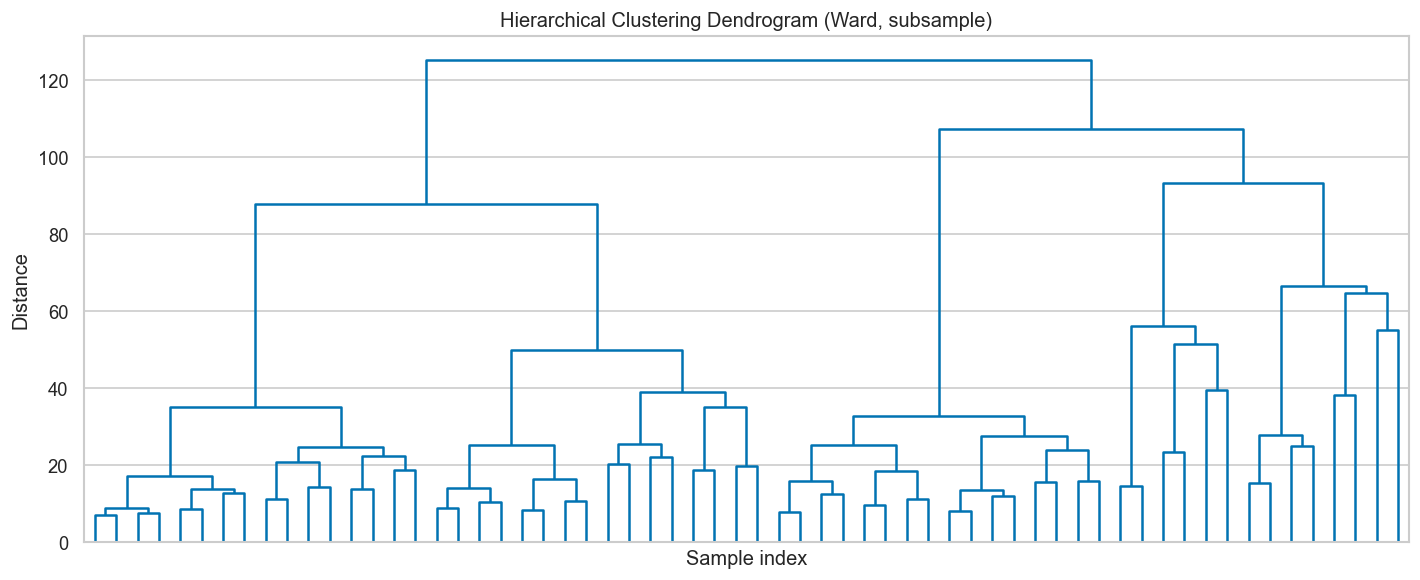

In [13]:
# Dendrogram on a subsample (full dataset too large)
sample_idx = np.random.default_rng(42).choice(len(X), size=min(2000, len(X)), replace=False)
X_sample = X[sample_idx]

linkage_matrix = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(linkage_matrix, truncate_mode="level", p=5, ax=ax,
           no_labels=True, color_threshold=0)
ax.set_title("Hierarchical Clustering Dendrogram (Ward, subsample)")
ax.set_xlabel("Sample index")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.savefig(out / "dendrogram.png", bbox_inches="tight")
plt.show()

In [14]:
# Run Agglomerative Clustering for each category-matched k
agglo_results = {}
for k in k_values:
    agglo = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agglo.fit_predict(X)
    df_clean[f"agglo_k{k}"] = labels
    agglo_results[k] = labels
    sil = silhouette_score(X, labels, sample_size=5000, random_state=42)
    print(f"Agglomerative k={k}: silhouette={sil:.4f}")

Agglomerative k=3: silhouette=0.1471


Agglomerative k=6: silhouette=0.0662


## 7. Cluster vs. Category Alignment

We measure alignment using:
- **Adjusted Rand Index (ARI)**: 1.0 = perfect match, 0.0 = random
- **Normalized Mutual Information (NMI)**: 1.0 = perfect correlation, 0.0 = independent

In [15]:
from sklearn.preprocessing import LabelEncoder

categories = {
    "gender": LabelEncoder().fit_transform(df_clean["gender"]),
    "ethnicity": LabelEncoder().fit_transform(df_clean["ethnicity"]),
    "dataset": LabelEncoder().fit_transform(df_clean["dataset"]),
}

results = []

# KMeans results
for k, labels in kmeans_results.items():
    for cat_name, cat_labels in categories.items():
        ari = adjusted_rand_score(cat_labels, labels)
        nmi = normalized_mutual_info_score(cat_labels, labels)
        results.append({
            "algorithm": "KMeans",
            "k": k,
            "category": cat_name,
            "ARI": ari,
            "NMI": nmi,
        })

# Agglomerative results
for k, labels in agglo_results.items():
    for cat_name, cat_labels in categories.items():
        ari = adjusted_rand_score(cat_labels, labels)
        nmi = normalized_mutual_info_score(cat_labels, labels)
        results.append({
            "algorithm": "Agglomerative",
            "k": k,
            "category": cat_name,
            "ARI": ari,
            "NMI": nmi,
        })

# DBSCAN results (only non-noise points)
if n_clusters_dbscan > 1:
    mask_no_noise = dbscan_labels != -1
    for cat_name, cat_labels in categories.items():
        ari = adjusted_rand_score(cat_labels[mask_no_noise], dbscan_labels[mask_no_noise])
        nmi = normalized_mutual_info_score(cat_labels[mask_no_noise], dbscan_labels[mask_no_noise])
        results.append({
            "algorithm": "DBSCAN",
            "k": n_clusters_dbscan,
            "category": cat_name,
            "ARI": ari,
            "NMI": nmi,
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

    algorithm  k  category      ARI      NMI
       KMeans  3    gender 0.174143 0.191573
       KMeans  3 ethnicity 0.146409 0.124463
       KMeans  3   dataset 0.176273 0.195612
       KMeans  6    gender 0.135435 0.209297
       KMeans  6 ethnicity 0.049669 0.106346
       KMeans  6   dataset 0.179830 0.243074
Agglomerative  3    gender 0.119778 0.154898
Agglomerative  3 ethnicity 0.192174 0.127609
Agglomerative  3   dataset 0.117837 0.159715
Agglomerative  6    gender 0.136893 0.193314
Agglomerative  6 ethnicity 0.061879 0.120501
Agglomerative  6   dataset 0.164678 0.228910


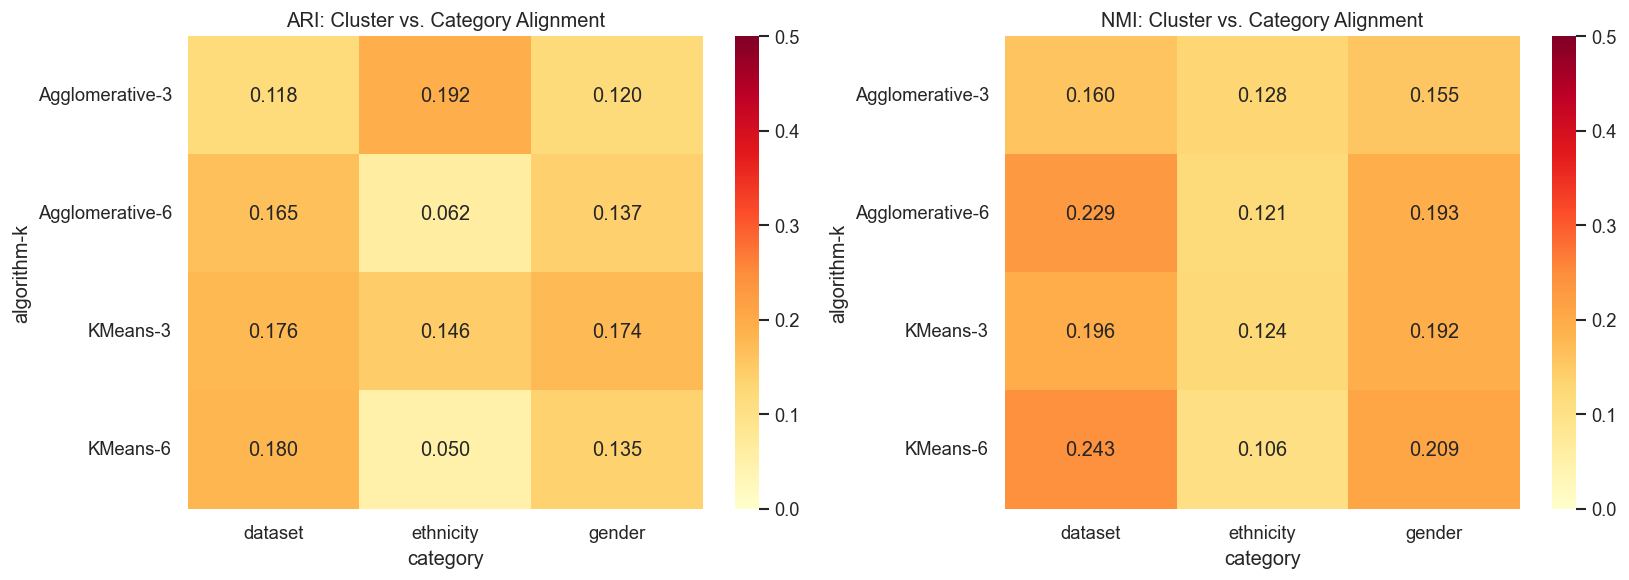

In [16]:
# Heatmap of NMI scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip([ax1, ax2], ["ARI", "NMI"]):
    pivot = results_df.pivot_table(index=["algorithm", "k"], columns="category", values=metric)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax, vmin=0, vmax=0.5)
    ax.set_title(f"{metric}: Cluster vs. Category Alignment")

plt.tight_layout()
plt.savefig(out / "alignment_heatmap.png", bbox_inches="tight")
plt.show()

## 8. Detailed Cross-Tabulation

For the best-performing cluster assignment, show how cluster membership distributes across categories.


KMeans k=3 vs gender (row-normalized):
kmeans_k3      0      1      2
gender                        
female     0.590  0.402  0.008
male       0.496  0.499  0.005
unknown    0.066  0.736  0.198


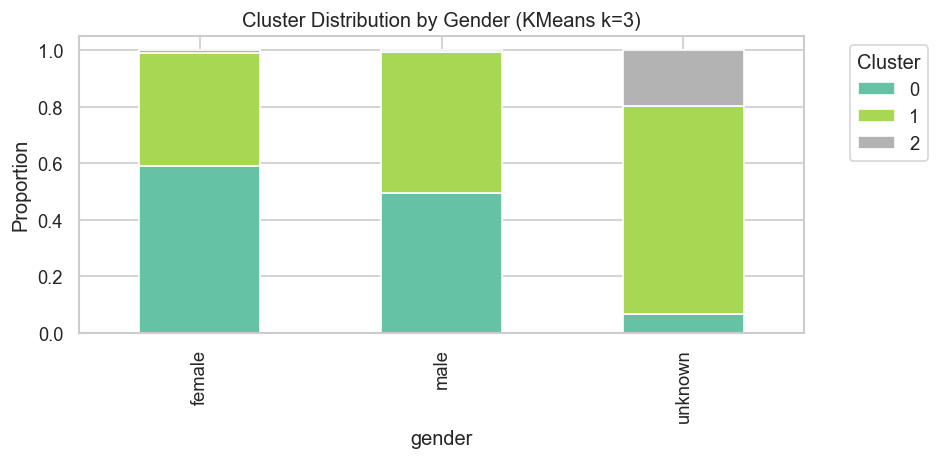


KMeans k=6 vs ethnicity (row-normalized):
kmeans_k6       0      1      2      3      4      5
ethnicity                                           
asian       0.226  0.053  0.282  0.122  0.073  0.244
black       0.182  0.247  0.128  0.030  0.341  0.071
caucasian   0.070  0.427  0.308  0.003  0.171  0.021
hispanic    0.176  0.233  0.236  0.010  0.324  0.020
indian      0.090  0.276  0.192  0.000  0.417  0.026
mideastern  0.096  0.144  0.323  0.003  0.388  0.045


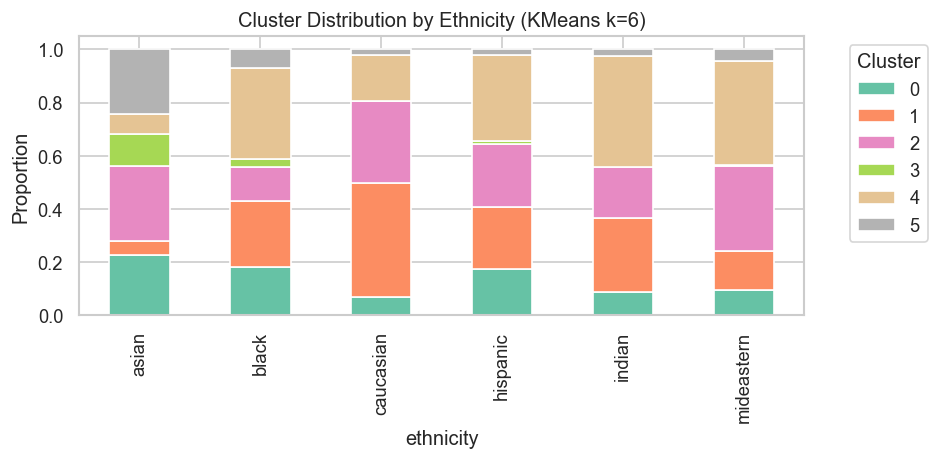


KMeans k=3 vs dataset (row-normalized):
kmeans_k3       0      1      2
dataset                        
livebeauty  0.066  0.736  0.198
mebeauty    0.503  0.478  0.019
scut        0.563  0.436  0.001


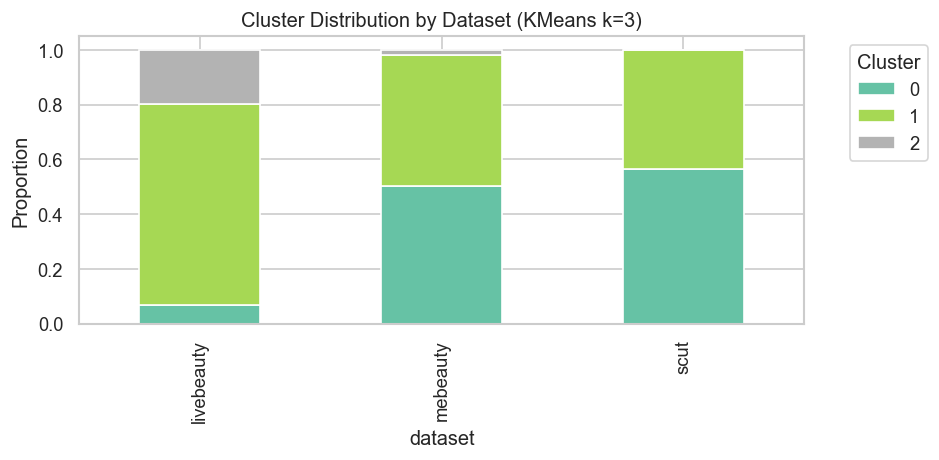

In [17]:
# Pick KMeans with category-matched k for each category
for cat_name, n_cat in [("gender", n_genders), ("ethnicity", n_ethnicities), ("dataset", n_datasets)]:
    col = f"kmeans_k{n_cat}"
    if col not in df_clean.columns:
        continue
    ct = pd.crosstab(df_clean[cat_name], df_clean[col], normalize="index")
    print(f"\n{'='*60}")
    print(f"KMeans k={n_cat} vs {cat_name} (row-normalized):")
    print(f"{'='*60}")
    print(ct.round(3).to_string())
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
    ax.set_title(f"Cluster Distribution by {cat_name.title()} (KMeans k={n_cat})")
    ax.set_ylabel("Proportion")
    ax.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(out / f"crosstab_kmeans_{cat_name}.png", bbox_inches="tight")
    plt.show()

## 9. PCA Visualization of Clusters

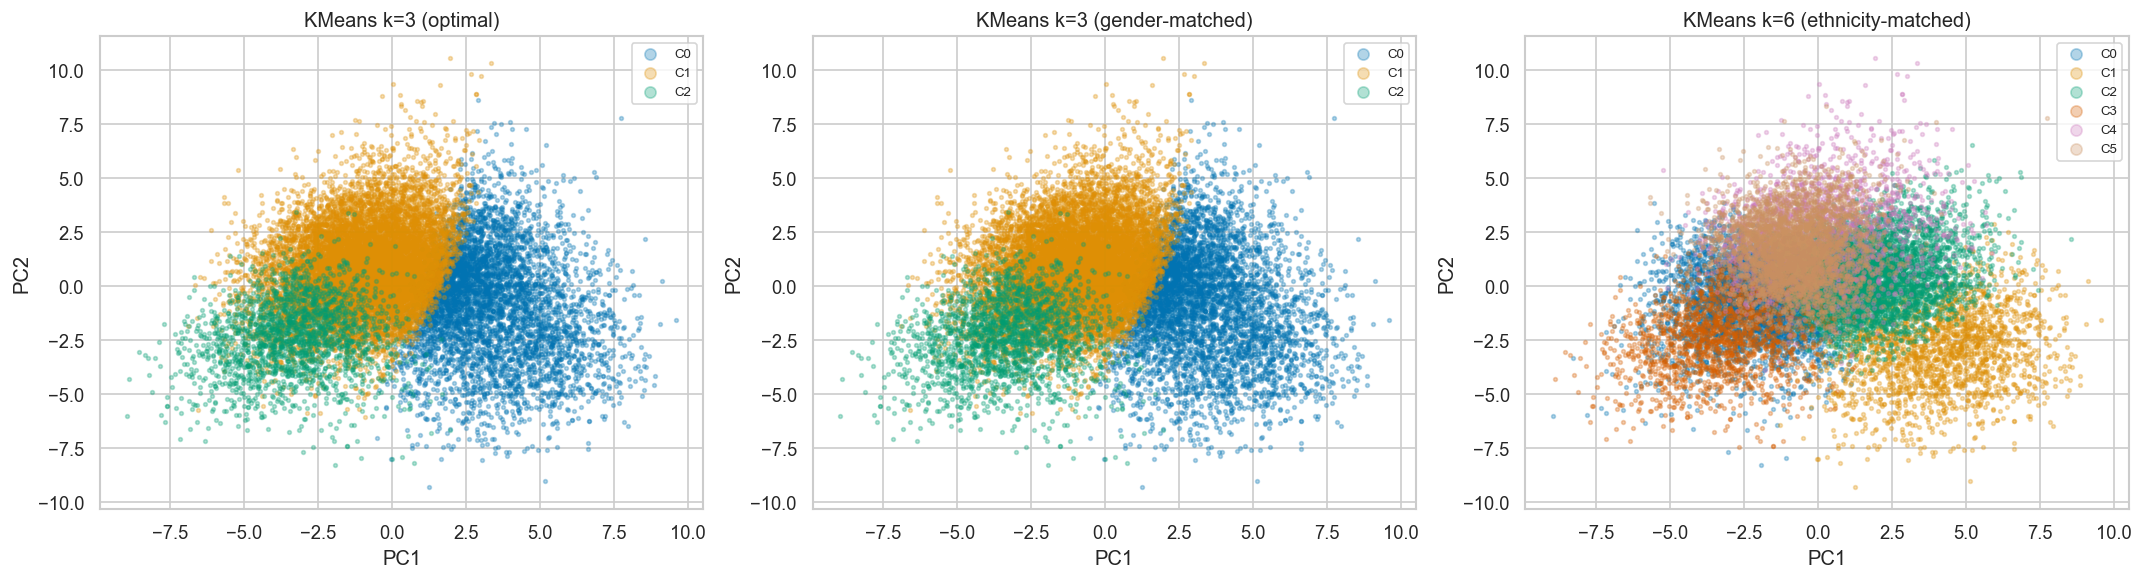

In [18]:
# Visualize best KMeans (optimal k) in PCA space
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Optimal k clusters
col = f"kmeans_k{best_k}"
for cluster in range(best_k):
    mask = df_clean[col] == cluster
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.3, s=5, label=f"C{cluster}")
axes[0].set_title(f"KMeans k={best_k} (optimal)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=3, fontsize=8)

# Gender-matched k
col = f"kmeans_k{n_genders}"
if col in df_clean.columns:
    for cluster in range(n_genders):
        mask = df_clean[col] == cluster
        axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.3, s=5, label=f"C{cluster}")
    axes[1].set_title(f"KMeans k={n_genders} (gender-matched)")
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")
    axes[1].legend(markerscale=3, fontsize=8)

# Ethnicity-matched k
col = f"kmeans_k{n_ethnicities}"
if col in df_clean.columns:
    for cluster in range(n_ethnicities):
        mask = df_clean[col] == cluster
        axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.3, s=5, label=f"C{cluster}")
    axes[2].set_title(f"KMeans k={n_ethnicities} (ethnicity-matched)")
    axes[2].set_xlabel("PC1")
    axes[2].set_ylabel("PC2")
    axes[2].legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig(out / "pca_clusters.png", bbox_inches="tight")
plt.show()

## 10. Feature Importance per Cluster

Which features differ most between clusters?

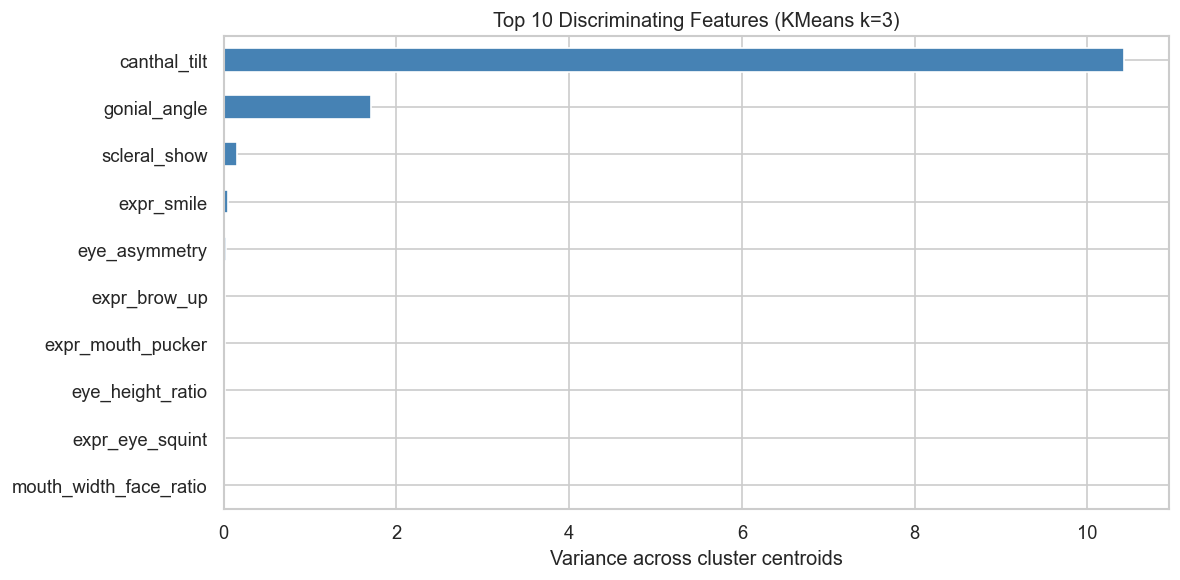


Cluster centroids (top features):
           canthal_tilt  gonial_angle  scleral_show  expr_smile  eye_asymmetry  expr_brow_up  expr_mouth_pucker  eye_height_ratio  expr_eye_squint  mouth_width_face_ratio
kmeans_k3                                                                                                                                                                 
0                7.1255      148.4413       -0.1296      0.4418         0.0438        0.1117             0.0371            0.3343           0.4325                  0.9184
1                5.2288      145.9210       -0.1017      0.0238         0.0418        0.3788             0.2809            0.3421           0.2895                  0.7680
2                0.8325      147.7763       -0.8092      0.0515         0.3286        0.3441             0.2841            0.0947           0.5269                  0.7459


In [19]:
# Use optimal-k KMeans clusters
col = f"kmeans_k{best_k}"
cluster_means = df_clean.groupby(col)[FEATURE_COLS].mean()

# Features with highest variance across cluster centroids
centroid_var = cluster_means.var()
top_features = centroid_var.nlargest(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_features.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Variance across cluster centroids")
ax.set_title(f"Top 10 Discriminating Features (KMeans k={best_k})")
plt.tight_layout()
plt.savefig(out / "feature_importance_clusters.png", bbox_inches="tight")
plt.show()

print("\nCluster centroids (top features):")
print(cluster_means[top_features.index].round(4).to_string())

## 11. Summary

In [20]:
print("=" * 60)
print("CLUSTERING ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nDataset: {len(df_clean)} samples, {len(FEATURE_COLS)} numeric features")
print(f"PCA: 2 components explain {sum(pca.explained_variance_ratio_)*100:.1f}% variance")
print(f"PCA: {pca_full.n_components_} components explain 95% variance")
print(f"\nOptimal k (silhouette): {best_k}")
print(f"DBSCAN clusters: {n_clusters_dbscan} (noise: {n_noise})")

print(f"\n{'─'*60}")
print("Alignment Scores (higher = clusters match category better):")
print(f"{'─'*60}")

# Best alignment for each category
for cat in ["gender", "ethnicity", "dataset"]:
    cat_results = results_df[results_df["category"] == cat]
    best_row = cat_results.loc[cat_results["NMI"].idxmax()]
    print(f"\n  {cat.upper()}:")
    print(f"    Best: {best_row['algorithm']} k={int(best_row['k'])} "
          f"(ARI={best_row['ARI']:.3f}, NMI={best_row['NMI']:.3f})")

print(f"\n{'─'*60}")
print("Interpretation:")
print("  ARI ~ 0 and NMI ~ 0: Clusters do NOT correspond to this category")
print("  ARI > 0.1 or NMI > 0.1: Some alignment exists")
print("  ARI > 0.3 or NMI > 0.3: Strong alignment")
print("=" * 60)

CLUSTERING ANALYSIS SUMMARY

Dataset: 17870 samples, 39 numeric features
PCA: 2 components explain 33.6% variance
PCA: 19 components explain 95% variance

Optimal k (silhouette): 3
DBSCAN clusters: 1 (noise: 371)

────────────────────────────────────────────────────────────
Alignment Scores (higher = clusters match category better):
────────────────────────────────────────────────────────────

  GENDER:
    Best: KMeans k=6 (ARI=0.135, NMI=0.209)

  ETHNICITY:
    Best: Agglomerative k=3 (ARI=0.192, NMI=0.128)

  DATASET:
    Best: KMeans k=6 (ARI=0.180, NMI=0.243)

────────────────────────────────────────────────────────────
Interpretation:
  ARI ~ 0 and NMI ~ 0: Clusters do NOT correspond to this category
  ARI > 0.1 or NMI > 0.1: Some alignment exists
  ARI > 0.3 or NMI > 0.3: Strong alignment
